# Imports, Installations and Downloads

In [40]:
%matplotlib inline
import torch as t
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt

# Data Processing

This notebook uses the datasets and transforms modules from the torchvision module to extract and transfrom data.

In [41]:
# Define tranformer ny normalising the data to have mean of 0 and standard deviation of 1
transform = transforms.Compose([
    transforms.ToTensor(), # Convert PIL Image to tensor
    transforms.Normalize((0.0,), (1.0,)),   # Normalise data using standardisation
    transforms.Lambda(lambda x: x.flatten())    # Flatten the image
])

# Install and transform training data
train_dataset = datasets.FashionMNIST(
    root="./data/train",
    train=True,
    download=True,
    transform=transform
)

# Install and transfrom test data
test_dataset = datasets.FashionMNIST(
    root="./data/test",
    train=False,
    download=True,
    transform=transform
)

In [42]:
# Split the train data into train and validation sets
train_size = int((5/6)*len(train_dataset))
val_size = len(train_dataset) - train_size

train_set, val_set = random_split(train_dataset, [train_size, val_size])

# Define and store the loaders into a global variable
global _LOADERS
_LOADERS = {
    "train": DataLoader(train_set, batch_size=50, shuffle=True),
    "val": DataLoader(val_set, batch_size=50),
    "test": DataLoader(test_dataset, batch_size=50)
}

In [43]:
# Check the size of the datasets
print(f"Training data size = {len(_LOADERS["train"].dataset)}")
print(f"Validation data size = {len(_LOADERS["val"].dataset)}")
print(f"Test data size = {len(_LOADERS["test"].dataset)}")

data_batch, labels_batch = next(iter(_LOADERS["train"]))
print(f"Shape of the data batch: {data_batch.shape}")
print(f"Shape of the labels batch: {labels_batch.shape}")

Training data size = 50000
Validation data size = 10000
Test data size = 10000
Shape of the data batch: torch.Size([50, 784])
Shape of the labels batch: torch.Size([50])


# 2. Building and training a Baseline model

In [44]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim: int, h1_dim: int, h2_dim: int, num_classes: int):
        """
        Initialises a MultiLayerPerceptron object.
        Parameters:
            input_dim: An int represent the number of features in a data point.
            h1_dim: An int represent the number of neurons in the first hidden layer.
            h2_dim: An int represent the number of neurons in the second hidden layer.
            num_classes: An int represent the number of classes.
        Returns:
            Nothing.
        """
        super(MultiLayerPerceptron, self).__init__()
        # Defining layers of the MultiLayer perceptron
        self.hidden_layer1 = nn.Linear(input_dim, h1_dim)
        self.hidden_layer2 = nn.Linear(h1_dim, h2_dim)
        self.output_layer = nn.Linear(h2_dim, num_classes)

    def forward(self, mini_batch: t.Tensor) -> t.Tensor:
        """
        Implements a forward pass for neural network training.
        Parameters:
            mini_batch: A tensor object representing a mini batch of the dataset.
        Returns:
            A tensor object representing the probabilities of each data point in the mini batch.
        """
        # Pass input through the first hidden dimension and apply ReLu
        h1_out = t.relu(self.hidden_layer1(mini_batch))
        # Pass input through the second hidden dimension and apply ReLu
        h2_out = t.relu(self.hidden_layer2(h1_out))
        # Pass the result through the output layer and apply the sigmoid function
        props = t.sigmoid(self.output_layer(h2_out))
        return props
    
    def predict(self, mini_batch: t.Tensor) -> t.Tensor:
        """
        Implements a forward pass for neural network training.
        Parameters:
            mini_batch: A tensor object representing a mini batch of the dataset.
        Returns:
            A tensor object representing the predicted class for each data point in the mini batch.
        """
        logits = self.forward(mini_batch)
        return t.argmax(logits, dim=1)

In [47]:
def set_deterministic_seed(seed: int = 2) -> None:
    """
    Set all seeds for deterministic behavior
    Parameters:
        seed: An int representing a seed.
    Returns:
        None.
    """
    t.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    # For CUDA machines that have CUDA
    if t.cuda.is_available():
        t.cuda.manual_seed(seed)
        t.cuda.manual_seed_all(seed)
        t.backends.cudnn.deterministic = True
        t.backends.cudnn.benchmark = False
        
def train_model(
        model: MultiLayerPerceptron,
        criterion: nn,
        optimiser: t.optim, 
        num_epochs: int = 50,
        early_stopping: bool = False, 
        val_thrs: float = 0.85, 
        patience: int = 5
    ) -> dict:
    """
    Implements a training loop.
    Parameters:
        model: A MultiLayerPerceptron object representing a model.
        criterion: An nn module representing a loss function.
        optimiser: A t.optim module representing an optimiser function.
        num_epochs: An int representing the number of epochs the model is to train.
        early_stopping: A bool value used to deternmining whether or not to use early stopping.
        val_thrs: A float representing the minimum validation accuracy sought for.
        patience: An int representing the number of epochs the validation accuracy is allowed to drop consecutively.
    Returns:
        A dictionary of the training results.
    """
    # Set seed for determinism
    set_deterministic_seed()

    # Track losses and accuracies
    training_loss, validation_loss = [], []
    training_accuracy, validation_accuracy = [], []

    epochs_no_improve = 0

    for _ in range(num_epochs):
        model.train()
        total_train_loss, correct_train, total_train_samples = 0.0, 0, 0
        # Iterate through the training set batch by batch
        for batch_X, batch_y in _LOADERS["train"]:
            # Forward pass
            outputs = model(batch_X)
            ce_loss = criterion(outputs, batch_y)

            # Reset the gradients from the previous steps
            optimiser.zero_grad()

            # Backpropagation
            ce_loss.backward()
            optimiser.step()

            # Update total training loss
            total_train_loss += ce_loss.item()

            # Compute accuracy efficiently
            with t.no_grad():
                train_preds = model.predict(batch_X)
                correct_train += (train_preds == batch_y).sum().item()
                total_train_samples += batch_y.size(0)

        avg_train_loss = total_train_loss / len(_LOADERS["train"])
        train_acc = correct_train / total_train_samples

        # Compute validation loss and accuracy
        total_val_loss, correct_val, total_val_samples = 0.0, 0, 0
        model.eval()
        with t.no_grad():
            for batch_X_val, batch_y_val in _LOADERS["val"]:
                # Forward pass
                outputs_val = model(batch_X_val)
                val_loss = criterion(outputs_val, batch_y_val)
                total_val_loss += val_loss.item()

                # Compute accuracy efficiently
                with t.no_grad():
                    val_preds = model.predict(batch_X_val)
                    correct_val += (val_preds == batch_y_val).sum().item()
                    total_val_samples += batch_y_val.size(0)

        avg_val_loss = total_val_loss / len(_LOADERS["val"])
        val_acc = correct_val / total_val_samples

        # Save the metrics
        training_loss.append(round(avg_train_loss, 4))
        validation_loss.append(round(avg_val_loss, 4))
        training_accuracy.append(round(train_acc, 4))
        validation_accuracy.append(round(val_acc, 4))

        if early_stopping:
            if val_thrs <= val_acc:
                break

            if len(validation_accuracy) > 1 and validation_accuracy[-1] < validation_accuracy[-2]:
                epochs_no_improve += 1
            else:
                epochs_no_improve = 0

            if epochs_no_improve >= patience:
                break

    return {
        "Model": model,
        "Training Loss": training_loss,
        "Validation Loss": validation_loss,
        "Training Accuracy": training_accuracy,
        "Validation Accuracy": validation_accuracy
    }

def get_final_metrics(trained_model: MultiLayerPerceptron) -> dict:
    """
    Computes the final training and validation accuracies.
    Parameters:
        trained_model: A MultiLayerPerceptron objected representing the trained model.
    Returns:
        A dictionary of the final training and validation accuracies.
    """
    # Collect data and labels
    train_features, val_features = [], []
    train_labels, val_labels = [], []

    # Iterate over data loaders
    for t_feats, t_labels in _LOADERS["train"]:
        train_features.append(t_feats)
        train_labels.append(t_labels)

    for v_feats, v_labels in _LOADERS["val"]:
        val_features.append(v_feats)
        val_labels.append(v_labels)

    # Concatenate the Batches
    X_train = t.cat(train_features, dim=0)
    X_val = t.cat(val_features, dim=0)
    y_train = t.cat(train_labels, dim=0)
    y_val = t.cat(val_labels, dim=0)

    # Compute accuracies
    trained_model.eval()
    with t.no_grad():
        # Final training accuracy
        final_train_preds = trained_model.predict(X_train)
        final_train_acc = (final_train_preds == y_train).float().mean().item()

        # Final validation accuracy
        final_val_preds = trained_model.predict(X_val)
        final_val_acc = (final_val_preds == y_val).float().mean().item()

    return {
        "Final Train Acc": final_train_acc,
        "Final Val Acc": final_val_acc
    }

def plot_training_results(train_results: dict) -> None:
    """
    Plots the training and validation losses and accuracies from the training results.
    Parameters:
        train_results: A dictionary storing a model's training results.
    Returns:
        None
    """
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    # Left plot
    ax[0].plot(train_results["Training Loss"], marker='o', linestyle='--', color='blue', label='Train Loss')
    ax[0].plot(train_results["Validation Loss"], marker='o', linestyle='--', color='green', label="Val loss")
    ax[0].set_xlabel('Number of epochs')
    ax[0].set_ylabel('Loss (cross-entropy loss)')
    ax[0].set_title("Model Loss over Epochs")
    ax[0].grid(True)
    ax[0].legend()

    # Right plot
    ax[1].plot(train_results["Training Accuracy"], marker='o', linestyle='--', color='red', label='Train Acc')
    ax[1].plot(train_results["Validation Accuracy"], marker='o', linestyle='--', color='orange', label="Val Acc")
    ax[1].set_xlabel('Number of epochs')
    ax[1].set_ylabel('Accuracy (as a percentange)')
    ax[1].set_title("Model Accuracy over Epochs")
    ax[1].grid(True)
    ax[1].legend()
  
    fig.tight_layout()
    plt.show()

In [48]:
"""Training my BaseLIne model"""
# Create an instance of the MultilayeredPerceptron
model = MultiLayerPerceptron(data_batch.shape[1], 128, 64, 10)
# Define a loss function and an optimiser using lr=0.001
criterion = nn.CrossEntropyLoss()
optimiser = t.optim.Adam(model.parameters(), lr=0.001)

# Train the model
train_results = train_model(model, criterion, optimiser, num_epochs=10)

final_metrics = get_final_metrics(train_results["Model"])

# Display baseline metrics
print(f"Baseline training accuracy = {final_metrics["Final Train Acc"]:.4f}")
print(f"Baseline validation accuracy = {final_metrics["Final Val Acc"]:.4f}")


Baseline training accuracy = 0.8758
Baseline validation accuracy = 0.8669


In [49]:
data_frame = pd.DataFrame(train_results, columns=["Training Loss", "Validation Loss", "Training Accuracy", "Validation Accuracy"])
print(data_frame)

   Training Loss  Validation Loss  Training Accuracy  Validation Accuracy
0         1.6759           1.6320             0.4971               0.5455
1         1.6137           1.6018             0.5901               0.6135
2         1.5942           1.5983             0.6522               0.6675
3         1.5834           1.5873             0.6949               0.6965
4         1.5751           1.5652             0.7395               0.8421
5         1.5531           1.5572             0.8575               0.8566
6         1.5492           1.5514             0.8617               0.8634
7         1.5457           1.5506             0.8675               0.8637
8         1.5422           1.5490             0.8697               0.8638
9         1.5401           1.5497             0.8726               0.8669


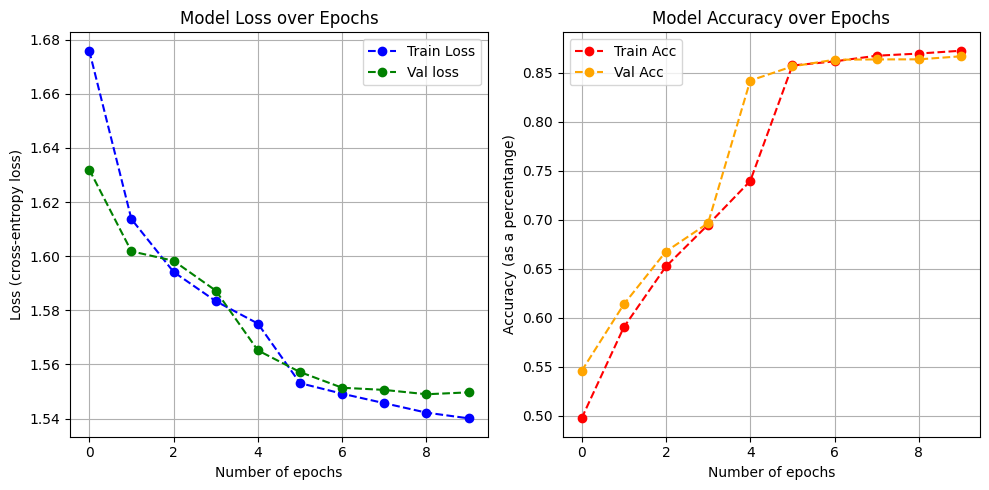

In [50]:
# Display the training results
plot_training_results(train_results)

## 3. Hyperparameter Optimisation Experiment

This notebook investigates the impact of the following hyperparameters on the models performance

* Learning rate = [0.0001, 0.001, 0.01, 0.1]
* Optimiser = [t.optim.Adam, t.optim.SGD, t.optim.RMSprop]
* Number of neurons in hedden layer one = [100, 200, 500, 700]

In [51]:
def grid_search(alphas: list, optimisers: list, num_neurons: list) -> dict:
    """
    Implements a grid search for hyperparameter tuning.
    Parameters:
        alphas: A list of learning rates.
        optimisers: A list of strings indicating which optimiser object to create.
        num_neurons: A list on integers representing the number oif neurons in the first hidden layer.
    Returns:
        A dictionary of the training results.
    """
    # Define criterion
    ctrn = nn.CrossEntropyLoss()
    # Store the final accuracies
    accuracies = []
    for neurons in num_neurons:
        model_ = MultiLayerPerceptron(data_batch.shape[1], neurons, 64, 10)
        for opt in optimisers:
            for lr in alphas:
                if opt == "Adam":
                    optimizer = t.optim.Adam(model_.parameters(), lr=lr)
                elif opt == "SGD":
                    optimizer = t.optim.SGD(model_.parameters(), lr=lr)
                elif opt == "RMSprop":
                    optimizer = t.optim.RMSprop(model_.parameters(), lr=lr)
                else:
                    raise ValueError("optimiser must be in [\"Adam\", \"SGD\", \"RMSprop\"]")
                
                # Train model
                tr_res = train_model(model_, ctrn, optimizer)
                f_metrics = get_final_metrics(tr_res["Model"])
                accuracies.append({
                    "Model": model_,
                    "neurons": neurons,
                    "optimiser": opt,
                    "lr": lr,
                    "Training Loss": tr_res["Training Loss"],
                    "Validation Loss": tr_res["Validation Loss"],
                    "Final Val Acc": f_metrics["Final Val Acc"]
                })
    return accuracies

In [ ]:
# Define tuning hyperparameters
alphas = [0.0001, 0.001, 0.01, 0.1]
optims = ["Adam", "SGD", "RMSprop"]
neurons = [100, 200, 500, 700]

grid_results = grid_search(alphas, optims, neurons)

## 4. Analysis and Report

This notebook uses the for reporting:
* ``matplotlib`` to plot the loss curve for the baseline model and best performing model.
* ``sklearn.metrics`` to define a confusion matrix for the best model's predictions on the validation set.
* ``pandas`` to present experimental results
* ``seaborn`` to clearly compare the hyperparameter impact on performance

In [ ]:
# Present the experimental results
